## Understanding Dataset

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')

### Data Exploration Summary

- There are 8807 rows and 12 columns in the dataframe

- The columns director, cast, country, date_added, rating, and duration have some NaN values and need to be cleaned

- The dataframe, however, is free from duplicate values

- The columns of description, date_added and rating will not be super useful in analysis, so I have dropped them in data cleaning

- The listed_in column has the typical genres of the movie/TV show, and is in the form of CSV and whitespaces; which are handled in the data cleaning. Also, the name of this column is renamed to 'genres'

## Data Cleaning

In [ ]:
df = df.drop(columns = ['description', 'date_added', 'rating'])         # dropping irrelevant columns

df = df.fillna(                     # filling missing values with '-'
    {
        'director' : '-',
        'cast' : '-',
        'duration' : '-',
    }
)

df = df.rename(columns =            # renameing 'listed_in' to 'genres'
    {
        "listed_in" : "genres",
    }
)

##### Now, splitting genres into a list and exploding the dataframe to have one genre per row for each movie

This is done to ease the process of finding the most watched genres

In [ ]:
df['genres'] = df['genres'].str.split(', ')

df = df.explode('genres').reset_index(drop = True)

## Data Visualization

As we proceed, many of our questions would be answered by values and plots of our data

### Q1. Is Netflix mostly Movies or TV Shows?



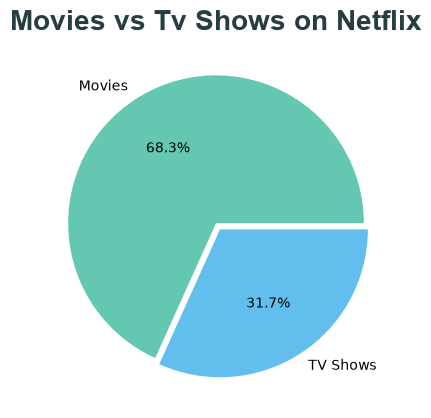

In [133]:
types = df["type"].value_counts()

plt.pie(types, 
        labels = ["Movies", "TV Shows"], 
        autopct = "%1.1f%%",
        colors = ["#63C7B2", "#62BFED"],
        explode = [0, 0.05],
)

plt.title("Movies vs Tv Shows on Netflix", fontweight = "bold", family = "Arial", fontsize = "20", color = "#263d42")

plt.show()

Ans - Movies roughly consitute 68.3% of the content on netflix, dominating over TV Shows, which were only 31.7%

<html>
<head></head>
<body><hr>
</body>
</html>

### Q2. How was the content growth from 2011 to 2020?



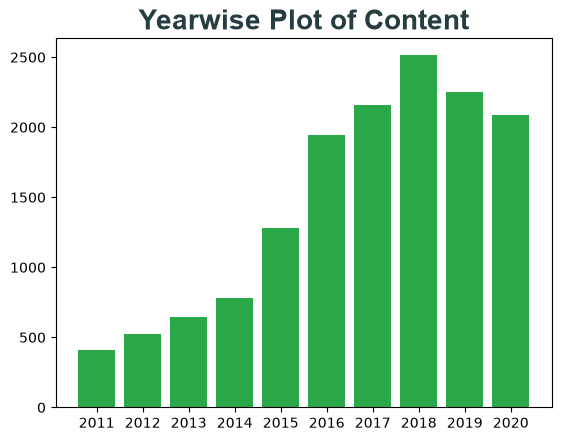

In [146]:
yearly = df['release_year'].value_counts().sort_index()

years = [2011, '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']

plt.bar(years, yearly.loc[2011 : 2020], color = "#2BA84A")

plt.title("Yearwise Plot of Content", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

Ans - Netflix has grown exponentially with number of shows added per year reaching ~2500 in 2018 from ~400 in 2011.

<html>
<head></head>
<body><hr>
</body>
</html>

### Q3. What were the Top 10 Countries on Netflix?



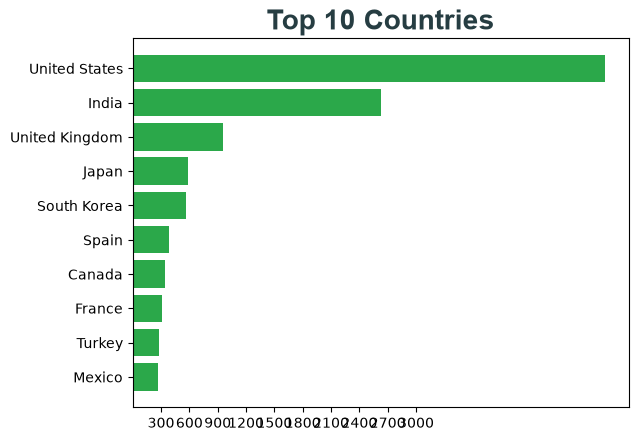

In [222]:
countries = df['country'].value_counts().reset_index()

top10 = countries.iloc[0:10].sort_values(by = 'count', ascending = True)

plt.barh(top10['country'], top10['count'], color = "#2BA84A")

plt.xticks([300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000])

plt.title("Top 10 Countries", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

Ans - United States (2818) dominated the content released, followed by India (972) and United Kingdom (419). It is evident 

that Netflix caters a diverse range of content to its viewers.

<html>
<head></head>
<body><hr>
</body>
</html>

### Q4. What were the Top 5 Genres on Netflix?

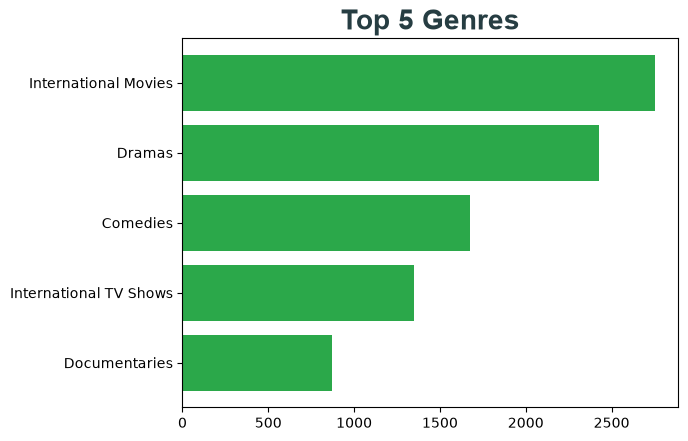

In [223]:
genres = df['genres'].value_counts().reset_index()

genres = genres.iloc[0:5].sort_values(by = 'count', ascending = True)

plt.barh(genres['genres'], genres['count'], color = "#2BA84A")

plt.title("Top 5 Genres", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

Ans - International Movies (2752) and Dramas (2427) dominate Netflix, followed by Comedies (1674), International TV Shows 

(1351) and Documentaries (869). These are the Top 5 Genres available on Netflix among the 40+ Genres on Netflix.

<html>
<head></head>
<body><hr>
</body>
</html>

### Q5. Which directors have the most movies on Netflix?

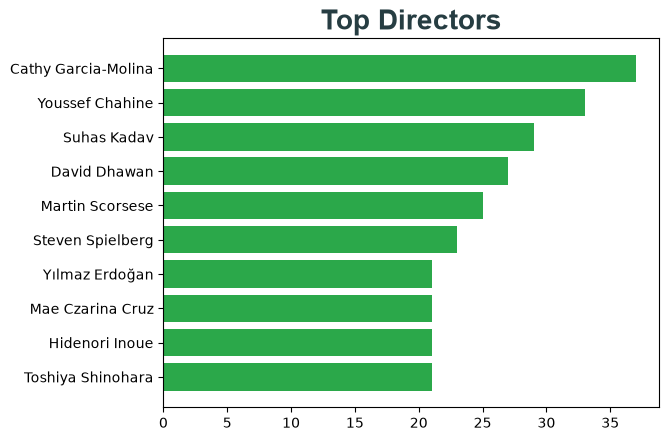

In [226]:
directors = df['director'].value_counts().reset_index()

directors = directors[directors['director'] != '-']

directors = directors.iloc[0:10].sort_values(by = 'count', ascending = True)

plt.barh(directors['director'], directors['count'], color = "#2BA84A")

plt.title("Top Directors", fontsize = 20, fontweight = "bold", family = 'Arial', color = '#263d42')

plt.show()

Ans - Cathy Garcia-Molina (37), a Filipino film director is the top known director on Netflix. Popular Indian names like Suhas Kadav (29) and 

David Dhawan (27) are also in the list. Popular American names like Martin Scoresese (25) and Steven Spielberg (23) are also in the list. 

<html>
<head></head>
<body><hr>
</body>
</html>

## Summary



### Overview

This analysis of the Netflix dataset revealed several important trends about the platform's content strategy and catalog composition.

- Netflix's library is dominated by Movies, which significantly outnumber TV Shows.

- The platform experienced substantial content growth between 2011 and 2020, with the largest expansion occurring in the later years as Netflix increased its global presence.

- The United States contributed the highest number of titles, followed by countries such as India and the United Kingdom, highlighting Netflix's strong international content portfolio.

- Drama, International Movies, Comedy, Documentaries, and Action & Adventure emerged as the most common genres, indicating a focus on diverse and globally appealing content.

- The analysis suggests that Netflix has increasingly invested in expanding both the quantity and variety of content to cater to audiences across different regions and preferences.

- Overall, Netflix's catalog demonstrates a strategy centered on global reach, genre diversity, and rapid content expansion, enabling the platform to serve a broad and international subscriber base.

### Key Insights

1. Movies constitute the majority of Netflix's catalog.

2. Content additions accelerated significantly after 2015, reflecting Netflix's expansion phase.

3. The United States remains the primary content source, while international markets contribute substantially to catalog diversity.

4. Drama and International content dominate the platform, indicating strong demand for globally relevant storytelling.

5. Netflix's content strategy appears focused on balancing mainstream entertainment with region-specific offerings to       
    
    attract a worldwide audience.

<html>
<head></head>
<body><hr>
</body>
</html>

# THANK YOU